# Reading in data

In [162]:
import pandas as pd 
import numpy as np
import re
import matplotlib.pyplot as plt
import math

In [163]:
df_24_25 = pd.read_csv('data/24_25_survey.csv')
df_23_24 = pd.read_csv('data/23_24_survey.csv')

# 23-24 Analysis

## Data Cleaning 

In [164]:
# Dropping garbage columns that we don't need.
df = df_23_24.drop(columns=['Timestamp',
                            'Please type your name below to be entered into a gift card drawing for a chance to win a gift card to Target, Krispy Kreme, Taco Bell, and more! There are 5 chances to win!   By submitting your name below you will receive an additional point for the 2023-2024 Housing Lottery.',
                            'Please type your name below to be entered into a gift card drawing for a chance to win a gift card to Target, Krispy Kreme, Taco Bell, and more! There are 5 chances to win!   By submitting your name below you will receive an additional point for the 2023-2024 Housing Lottery..1'])

# Cleaning up meal plan question because it was a free form response  
valid_plans = {
    "All Access 7",
    "All Access 5",
    "Block 160",
    "Block 100",
    "Block 50",
    "Commuter 80",
    "Commuter 300"
}

# Normalizing meal plan responses to match valid plans. 
def normalize_meal_plan(x):
    if pd.isna(x):
        return np.nan
    
    s = str(x).lower().strip()
    s = re.sub(r'[^a-z0-9\s]', '', s)
    s = re.sub(r'\s+', ' ', s)

    if any(k in s for k in ["no meal", "dont", "don't", "own food", "rather not"]):
        return np.nan

    if re.search(r'\b7\b|seven|aa7|full|largest|unlimited', s):
        return "All Access 7"
    
    if re.search(r'\b5\b|five', s):
        return "All Access 5"

    if "160" in s:
        return "Block 160"
    if "100" in s:
        return "Block 100"
    if "50" in s:
        return "Block 50"

    if "80" in s:
        return "Commuter 80"
    if "300" in s:
        return "Commuter 300"

    return np.nan

df["meal_plan_clean"] = df["What meal plan do you have?"].apply(normalize_meal_plan)
df["meal_plan_clean"].value_counts(dropna=False)

meal_plan_clean
All Access 5    122
Block 50         63
NaN              60
All Access 7     53
Block 100        13
Block 160         6
Commuter 80       1
Name: count, dtype: int64

## Random Ideas

In [165]:
# Chat gippity helped me figure out a way to think about breaking up these 
# questions into cateogories for analysis. We can support 3 
# specific areas of campus with this config:

# Operational performance
# ======================
# RA effectiveness
# Residence Life staff effectiveness
# Programming value
# Facilities & maintenance
# Safety & security
# Dining satisfaction

# Student success & retention drivers
# ===================================
# Sense of belonging
# Community climate
# Outcomes of living on campus
# Weekend engagement & programming demand

# Strategic planning
# ==================
# Building/floor experience differences
# Athlete vs non-athlete experience
# First-year vs upperclass experience
# Meal plan satisfaction & improvement opportunities

# So next, we engineer some features that will give us scores for 
# RA, staff, safety, facitities/services, community on campus, 
# & outcome of living on campus 

## Feature Engineering

In [166]:
# Converting likert responses to numeric
likert_map = {
    'Strongly Disagree': 1,
    'Disagree': 2,
    'Neutral': 3,
    'Agree': 4,
    'Strongly Agree': 5
}

for col in df.columns:
    df[col] = df[col].replace(likert_map)

C:\Users\bdupey\AppData\Local\Temp\ipykernel_62800\922892003.py:11: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].replace(likert_map)


In [167]:
# Identifying RA columns 
ra_cols = [c for c in df.columns if 'RA' in c and 'rate' in c]
df['RA_score'] = df[ra_cols].mean(axis=1)
ra_cols

['Please read the following statements regarding your fall semester RA and rate them. [It is easy to get in contact with my RA]',
 'Please read the following statements regarding your fall semester RA and rate them. [I am comfortable talking with my RA]',
 'Please read the following statements regarding your fall semester RA and rate them. [My RA has tried to get to know me]',
 'Please read the following statements regarding your fall semester RA and rate them. [My RA has helped me get to know other people]',
 'Please read the following statements regarding your fall semester RA and rate them. [My RA is a good source of information about campus & community resources]',
 'Please read the following statements regarding your fall semester RA and rate them. [My RA treats me with respect]',
 'Please read the following statements regarding your fall semester RA and rate them. [The RAs are consistent with regards to policy violations]',
 'Please read the following statements regarding your fa

In [168]:
# Assiging a staff score 
staff_cols = [c for c in df.columns if 'Residence Life staff' in c and 'Please share any additional comments' not in c]
df['staff_score'] = df[staff_cols].mean(axis=1)
staff_cols

['Please read the following statements regarding Residence Life staff and rate them. Residence Life staff includes Hall Directors (HD),  Assc. Director of Residence Life (Jori Van Beek), and Director of Residence Life (Robby Patterson). [My Hall Director has made an effort to be present in the building and get to know the residents in my community]',
 'Please read the following statements regarding Residence Life staff and rate them. Residence Life staff includes Hall Directors (HD),  Assc. Director of Residence Life (Jori Van Beek), and Director of Residence Life (Robby Patterson). [I know how to contact my HD if I have questions or need assistance]',
 'Please read the following statements regarding Residence Life staff and rate them. Residence Life staff includes Hall Directors (HD),  Assc. Director of Residence Life (Jori Van Beek), and Director of Residence Life (Robby Patterson). [Residence Life staff members are easy to contact when needed]',
 'Please read the following statement

In [169]:
# Creating safety score 
safety_cols = [c for c in df.columns if 'safety' in c.lower() and 'Please provide any additional feedback' not in c]
df['safety_score'] = df[safety_cols].mean(axis=1)
safety_cols

['Please read the following statements regarding safety and rate them. [I know how to contact Campus Security]',
 'Please read the following statements regarding safety and rate them. [When I contact Campus Security I know they will be able to help me]',
 'Please read the following statements regarding safety and rate them. [I feel safe in my room and on campus]',
 'Please read the following statements regarding safety and rate them. [I feel my belongings are safe in my room]',
 'Please read the following statements regarding safety and rate them. [I feel safe walking alone on campus at night]']

In [170]:
fac_cols = [c for c in df.columns if 'Facilities & Services' in c]
df['facilities_score'] = df[fac_cols].mean(axis=1)
fac_cols

['Please read the following statements regarding Residence Life Facilities & Services and rate them. [I feel satisfied with the cleanliness of my residence hall]',
 'Please read the following statements regarding Residence Life Facilities & Services and rate them. [I feel satisfied with the internet connectivity in my room]',
 'Please read the following statements regarding Residence Life Facilities & Services and rate them. [I feel satisfied with the laundry room facilities in my hall]',
 'Please read the following statements regarding Residence Life Facilities & Services and rate them. [I feel satisfied with the lounges in my hall]',
 'Please read the following statements regarding Residence Life Facilities & Services and rate them. [It is easy to study in my hall without noise interruptions]',
 'Please read the following statements regarding Residence Life Facilities & Services and rate them. [I can sleep without interruption in my hall]',
 'Please read the following statements rega

In [171]:
community_cols = [c for c in df.columns if 'community on campus' in c]
df['community_score'] = df[community_cols].mean(axis=1)
community_cols

['Please read the following statements regarding the community on campus and rate them. [I feel a strong sense of community among the people living in my residence hall]',
 'Please read the following statements regarding the community on campus and rate them. [My fellow residents respect people of differing races/ethnicity]',
 'Please read the following statements regarding the community on campus and rate them. [My fellow residents respect people of differing genders]',
 'Please read the following statements regarding the community on campus and rate them. [My fellow residents respect people of different sexual orientations]',
 'Please read the following statements regarding the community on campus and rate them. [My fellow residents respect people of differing religious beliefs]',
 'Please read the following statements regarding the community on campus and rate them. [My fellow residents respect people of differing political views]',
 'Please read the following statements regarding t

In [172]:
outcome_cols = [c for c in df.columns if 'outcome of living on campus' in c]
df['outcome_score'] = df[outcome_cols].mean(axis=1)
outcome_cols

['Please read the following statements regarding the outcome of living on campus and rate them. [My ability to make friends was enhanced by living on campus]',
 'Please read the following statements regarding the outcome of living on campus and rate them. [My ability to participate in campus organizations / athletics / events was enhanced by living on campus]',
 'Please read the following statements regarding the outcome of living on campus and rate them. [I am better able to manage my time because of living on campus]',
 'Please read the following statements regarding the outcome of living on campus and rate them. [I am a better problem solver because I have lived on campus]',
 'Please read the following statements regarding the outcome of living on campus and rate them. [I am better able to lead others because I have lived on campus]',
 'Please read the following statements regarding the outcome of living on campus and rate them. [I am better able to take responsibility for my action

## Exploratory Data Analysis

### Checking Distributions of Numeric Values

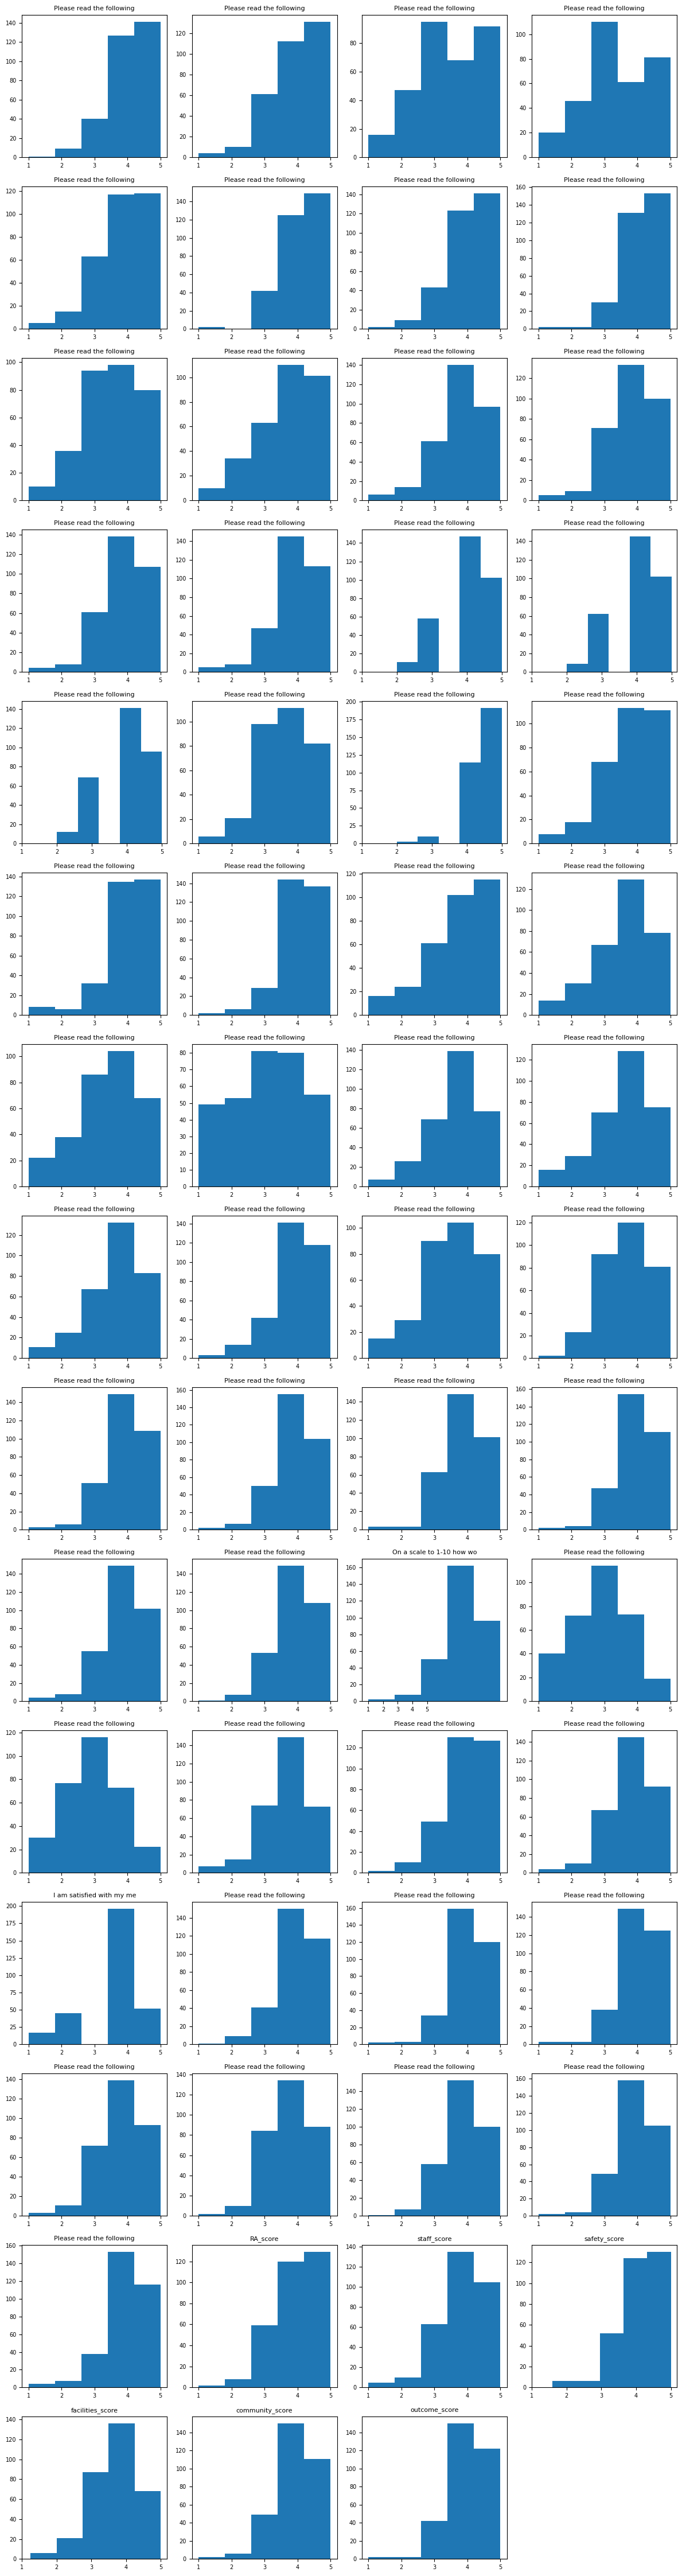

In [173]:
cols = list(num_cols)
n = len(cols)
ncols = 4  # adjust for width preference
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(12, 3*nrows))
axes = axes.flatten()

for i, col in enumerate(cols):
    ax = axes[i]
    ax.hist(df[col].dropna(), bins=5)
    ax.set_title(col[:25], fontsize=8)  # truncate long names
    ax.set_xticks([1,2,3,4,5])
    ax.tick_params(labelsize=7)

# remove empty subplots
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [174]:
# Lotta left skewed distributions here. Meaning we didn't hear as much from people who had negative experiences. 
# This is pretty common in survey data, but it does mean we need to be careful about how we interpret the results. 
# We can also look at the distribution of our engineered features to see if they are more normally distributed. 

## Score analysis

In [175]:
df[['RA_score','staff_score','safety_score',
    'facilities_score','community_score','outcome_score']].mean().sort_values()

facilities_score    3.670991
staff_score         3.928197
RA_score            4.035377
community_score     4.061995
outcome_score       4.113208
safety_score        4.172956
dtype: float64

In [176]:
# Looks like facilities scores the lowest, then staff. RA, community, outcome, and safety are 
# all pretty close to each other. 

In [177]:
df.corr(numeric_only=True)['On a scale to 1-10 how would your rate your sense of belonging / connection to Grand View University']\
  .sort_values(ascending=False)

On a scale to 1-10 how would your rate your sense of belonging / connection to Grand View University                                                                                                                                                                                                                                                            1.000000
Please read the following statements regarding the outcome of living on campus and rate them. [Living on campus has created a sense of belonging at Grand View University]                                                                                                                                                                                      0.552511
outcome_score                                                                                                                                                                                                                                                                         

In [178]:
df.groupby('Which Residence Hall did you live in during the fall semester?')['facilities_score'].mean().sort_values()
# Nielsen has the lowest facilities score. 

Which Residence Hall did you live in during the fall semester?
Nielsen Hall       3.394737
Knudsen Hall       3.521552
Hull Apartments    3.640625
L Apartments       3.661972
Hull Suites        3.732639
Langrock Suites    3.828947
Name: facilities_score, dtype: float64

In [179]:
df.groupby('Do you participate on a Grand View Athletic team?')['community_score'].mean()
# Athletes have a higher community score on average. Not surprising, but good to see it in the data.

Do you participate on a Grand View Athletic team?
No     3.853741
Yes    4.136752
Name: community_score, dtype: float64

In [180]:
df.groupby('What is your Class Status?')['RA_score'].mean()
# First years have a much higher RA score on average. Again, not surprising, but good to see it in the data.

What is your Class Status?
Freshman     4.150000
Junior       4.064063
Senior       3.942857
Sophomore    3.922194
Name: RA_score, dtype: float64

In [181]:
df.groupby('How many semesters have you lived on campus at Grand View?')['community_score'].mean()
# Interesting, the community score is highest for people in their first 2 semesters, then it drops off and is 
# lowest for people in their 5th+ semester. This could be a sign that people who have lived on campus longer 
# are more likely to have had negative experiences that have impacted their sense of community. Or it could be 
# that people who have lived on campus longer are more likely to be upperclassmen who are less engaged in the 
# community. This is something we can explore further with qualitative data or by looking at other variables in the survey.

How many semesters have you lived on campus at Grand View?
1-2 Semesters    4.172878
3-4 Semesters    4.007143
5+ Semesters     3.916667
Name: community_score, dtype: float64

In [182]:
df.columns

Index(['What is your Class Status?',
       'How many semesters have you lived on campus at Grand View?',
       'Are you currently 21 or older?',
       'Do you participate on a Grand View Athletic team?',
       'Which Residence Hall did you live in during the fall semester?',
       'What floor did you live on during the fall semester?',
       'Please read the following statements regarding your fall semester RA and rate them. [It is easy to get in contact with my RA]',
       'Please read the following statements regarding your fall semester RA and rate them. [I am comfortable talking with my RA]',
       'Please read the following statements regarding your fall semester RA and rate them. [My RA has tried to get to know me]',
       'Please read the following statements regarding your fall semester RA and rate them. [My RA has helped me get to know other people]',
       'Please read the following statements regarding your fall semester RA and rate them. [My RA is a good source of

In [183]:
score_cols  = [c for c in df.columns if 'score' in c]
score_cols

['RA_score',
 'staff_score',
 'safety_score',
 'facilities_score',
 'community_score',
 'outcome_score']

In [184]:
df.groupby('Which Residence Hall did you live in during the fall semester?')[score_cols]\
  .mean()\
  .sort_values(by=score_cols[0], ascending=False)

,RA_score,staff_score,safety_score,facilities_score,community_score,outcome_score
Which Residence Hall did you live in during the fall semester?,,,,,,
Langrock Suites,4.246711,3.993421,4.160526,3.828947,4.214286,4.314145
Hull Apartments,4.097656,4.010417,4.125000,3.640625,4.102679,3.945312
Nielsen Hall,4.042763,3.785088,4.352632,3.394737,3.943609,4.095395
L Apartments,4.031690,3.805164,4.033803,3.661972,4.058350,4.126761
Knudsen Hall,3.961207,3.925287,4.310345,3.521552,4.024631,4.043103
Hull Suites,3.814236,4.020833,4.194444,3.732639,3.964286,4.000000


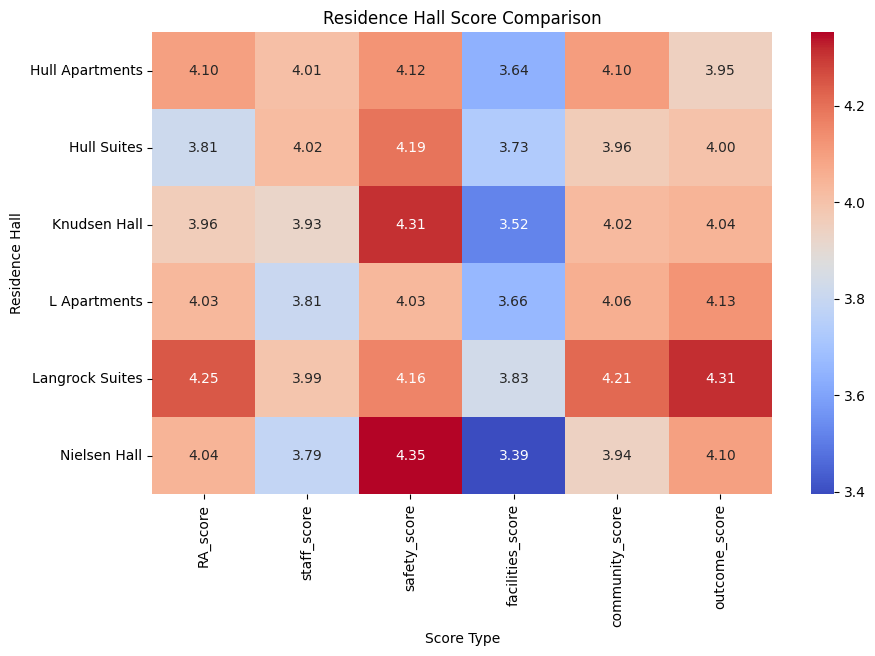

In [185]:
import seaborn as sns
import matplotlib.pyplot as plt

hall_scores = (
    df.groupby('Which Residence Hall did you live in during the fall semester?')[score_cols]
      .mean()
)

plt.figure(figsize=(10,6))
sns.heatmap(hall_scores, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Residence Hall Score Comparison")
plt.ylabel("Residence Hall")
plt.xlabel("Score Type")
plt.show()

In [186]:
df['Please read the following statements regarding Residence Life programming and rate them. [I would be more likely to stay on campus over the weekend if programs / events were provided more often on Friday / Saturday]'].mean()
# This is interesting. It seems like there is a decent amount of demand for more weekend programming, 
# which could be an opportunity for Residence Life to increase engagement and retention. We could also 
# look at the distribution of responses to this question to see if there are any patterns (e.g. do first 
# years want more weekend programming than upperclassmen?).

np.float64(3.761006289308176)

In [187]:
df[dining_cols]

,Please read the following statements regarding GV Dining and rate them. [I feel satisfied with the food quality on campus],Please read the following statements regarding GV Dining and rate them. [I feel satisfied with the variety & quality of food provided in the Student Center Dining Hall],Please read the following statements regarding GV Dining and rate them. [I feel satisfied with the variety & quality of food provided in GV Express],Please read the following statements regarding GV Dining and rate them. [I feel satisfied with the variety & quality of options provided at Einstein's Bagels ],Please read the following statements regarding GV Dining and rate them. [I feel satisfied with the level of customer service I receive from GV Dining employees],I am satisfied with my meal plan
0,4,3,3,5,5,4.0
1,2,2,3,3,4,2.0
2,3,3,3,3,3,NaN
3,2,2,4,5,4,1.0
4,3,3,5,5,3,4.0
...,...,...,...,...,...,...
313,3,3,3,5,5,4.0
314,4,4,4,4,4,NaN
315,3,3,3,3,3,4.0
316,5,5,5,5,5,4.0


In [188]:
dining_cols

['Please read the following statements regarding GV Dining and rate them. [I feel satisfied with the food quality on campus]',
 'Please read the following statements regarding GV Dining and rate them. [I feel satisfied with the variety & quality of food provided in the Student Center Dining Hall]',
 'Please read the following statements regarding GV Dining and rate them. [I feel satisfied with the variety & quality of food provided in GV Express]',
 "Please read the following statements regarding GV Dining and rate them. [I feel satisfied with the variety & quality of options provided at Einstein's Bagels ]",
 'Please read the following statements regarding GV Dining and rate them. [I feel satisfied with the level of customer service I receive from GV Dining employees]',
 'I am satisfied with my meal plan']

In [189]:
df['What meal plan do you have?'].unique()

array(['Block 50', nan, '50 block', '100', '50 swipes ',
       'The 50 swipes or whatever is the lowest option. ', 'BLOCK 50',
       'block 150', '50', '7days', 'block 100', '7 Day ', '5 day',
       "I don't even know ", 'Block 160', 'Block 100',
       '5 day all access ', '5 day meal plan', '5 block', '7 day',
       'All-Access 7', 'all access 5 ', 'All access 5', '5 day ',
       '5 day mean plan ', 'All-Access 5', '5-Day All Access', 'access 5',
       '5 day all access', '7 days all acess', 'all access 5',
       'All-access 5', '5 day pass', '5 day meal plan ', 'All Access 5',
       'All Acsess 5', 'I have the 5 day a week plan ', 'Access all 5 ',
       'full', '7 Day All Access', '5 days a week', 'all 5 ', 'acces 5',
       'All-Access 7 ', 'All access 7', 'All Access 7',
       'I have the largest one', '3 day ', '7 day a week ', '5-day', '7',
       '5 days ', '5 day access', 'all-5 access ', 'All-access ',
       'block 5 ', 'All 7', '7 day ', 'Full meal plan ', 'block 

In [190]:
df.groupby('meal_plan_clean')['I am satisfied with my meal plan'].mean().sort_values(ascending=True)
# Not surprisingly, the All Access 7 plan has the highest satisfaction, followed by All Access 5. 
# The block plans have lower satisfaction, with Block 50 being the lowest. The commuter plans have 
# the lowest satisfaction overall. This could be due to a variety of factors, such as the value 
# provided by the meal plan, the needs of the students on those plans, or other factors. This 
# is something we can explore further with qualitative data or by looking at other variables 
# in the survey.

meal_plan_clean
Block 50        3.507937
All Access 5    3.606557
Block 100       3.615385
All Access 7    4.038462
Block 160       4.500000
Commuter 80     5.000000
Name: I am satisfied with my meal plan, dtype: float64

In [191]:
dining_cols = ['Please read the following statements regarding GV Dining and rate them. [I feel satisfied with the food quality on campus]',
 'Please read the following statements regarding GV Dining and rate them. [I feel satisfied with the variety & quality of food provided in the Student Center Dining Hall]',
 'Please read the following statements regarding GV Dining and rate them. [I feel satisfied with the variety & quality of food provided in GV Express]',
 "Please read the following statements regarding GV Dining and rate them. [I feel satisfied with the variety & quality of options provided at Einstein's Bagels ]",
 'Please read the following statements regarding GV Dining and rate them. [I feel satisfied with the level of customer service I receive from GV Dining employees]',
 'I am satisfied with my meal plan']
df[dining_cols].mean().sort_values()
# Looks like the lowest rated aspect of dining is the variety & quality of options at Einstein's Bagels, followed by the variety & quality of food at GV Express. 
# The highest rated aspect is the level of customer service from GV Dining employees. This could be an opportunity for improvement in the dining options, 
# particularly at Einstein's Bagels and GV Express. We could also look at the distribution of responses to these questions to see if there are any patterns 
# (e.g. do people on certain meal plans have different satisfaction levels with dining?).


Please read the following statements regarding GV Dining and rate them. [I feel satisfied with the food quality on campus]                                                  2.871069
Please read the following statements regarding GV Dining and rate them. [I feel satisfied with the variety & quality of food provided in the Student Center Dining Hall]    2.937107
I am satisfied with my meal plan                                                                                                                                            3.712903
Please read the following statements regarding GV Dining and rate them. [I feel satisfied with the variety & quality of food provided in GV Express]                        3.836478
Please read the following statements regarding GV Dining and rate them. [I feel satisfied with the level of customer service I receive from GV Dining employees]            3.977987
Please read the following statements regarding GV Dining and rate them. [I feel satisfied with 

In [192]:
df.columns

Index(['What is your Class Status?',
       'How many semesters have you lived on campus at Grand View?',
       'Are you currently 21 or older?',
       'Do you participate on a Grand View Athletic team?',
       'Which Residence Hall did you live in during the fall semester?',
       'What floor did you live on during the fall semester?',
       'Please read the following statements regarding your fall semester RA and rate them. [It is easy to get in contact with my RA]',
       'Please read the following statements regarding your fall semester RA and rate them. [I am comfortable talking with my RA]',
       'Please read the following statements regarding your fall semester RA and rate them. [My RA has tried to get to know me]',
       'Please read the following statements regarding your fall semester RA and rate them. [My RA has helped me get to know other people]',
       'Please read the following statements regarding your fall semester RA and rate them. [My RA is a good source of

In [199]:
df['What are the main areas that positively impact your sense of belonging / connection to Grand View University'].unique()



array(['Involvement in an athletic team, Positive relationships with your instructors, Positive relationships with your coaches, Campus Size',
       'Involvement in a campus club / organization, Involvement in Student Leadership, Involvement in an athletic team, Campus Size',
       'Involvement in your major, Involvement in a campus club / organization, Involvement in Student Leadership, Involvement in an athletic team',
       'Involvement in your major, Involvement in an athletic team, Positive relationships with your instructors',
       'Involvement in a campus club / organization, Positive relationships with your instructors, Participating in REC/SAC events, Participating in academic extracurriculars (Research, Conferences, etc)',
       'Involvement in your major, Involvement in a campus club / organization, Campus Size',
       'Involvement in an athletic team, Positive relationships with staff members, Campus Size',
       'Involvement in a campus club / organization, Positiv

In [ ]:
col = 'What are the main areas that positively impact your sense of belonging / connection to Grand View University'

belonging = (
    df[[col, 'community_score']]
    .dropna(subset=[col])
    .assign(area=lambda d: d[col].str.split(','))
    .explode('area')
)

belonging['area'] = belonging['area'].str.strip()

belonging.groupby('area')['community_score'] \
    .agg(['mean','count']) \
    .sort_values('mean', ascending=False)


# Very strong signals
# Having a mentor on campus shows the highest association with community belonging.
# Residential community experience is a major driver of connection.
# REC/SAC events and intramural participation are strongly associated with higher community scores.
# Positive relationships with coaches and structured team environments strengthen belonging.
# Athletic participation is the dominant connection pathway due to both strong scores and high participation.

# Less strong signals: 
# Campus clubs/orgs (~3.80)
# Choir/Band/Performances (~3.77)
# Academic extracurriculars (~3.66)

# Key takeaways
# Belonging is strongest where relationships and structured involvement intersect.
# Athletics and residential living function as primary engines of student connection.
# Mentorship appears to be a high-impact, scalable belonging intervention.
# Clubs and academic extracurriculars show weaker connection signals and may need strengthening.
# A small group reporting no sense of belonging represents an early retention risk.

,mean,count
area,,
Having a mentor on campus,4.459184,14
Your residential community,4.267081,46
Participating in REC/SAC events,4.250000,52
Positive relationships with your coaches,4.238095,102
Participating in intramural sports,4.222222,18
Involvement in an athletic team,4.122024,192
Campus Size,4.120690,116
Campus Location,4.114719,66
Your campus job,4.065637,37


In [197]:
df.groupby('What are the main areas that positively impact your sense of belonging / connection to Grand View University')['community_score'].mean()

What are the main areas that positively impact your sense of belonging / connection to Grand View University
Campus Location                                                                                                                                              5.000000
Campus Location, Participating in intramural sports                                                                                                          5.000000
Campus Size, Campus Location                                                                                                                                 3.357143
Campus Size, Campus Location, Your residential community, Participating in REC/SAC events                                                                    5.000000
Friends                                                                                                                                                      3.142857
                                                             

In [193]:
score_cols

['RA_score',
 'staff_score',
 'safety_score',
 'facilities_score',
 'community_score',
 'outcome_score']

In [194]:
df.groupby('How many residence life programs/events did you attend this school year')['community_score'].mean()

How many residence life programs/events did you attend this school year
1-2 events    3.958525
3-4 events    4.294833
5+ events     4.121212
Name: community_score, dtype: float64

## What do we know so far?

In [ ]:
# I think that grouping columns is a good idea. We need a way to make different surveys "talk to each other".
# So we can group questions into the collowing categories: Operational Performance, Student Success & Retention Drivers, 
# and Strategic Planning. This will help us structure our analysis and recommendations in a way that 
# is actionable for the Residence Life team.

# Key findings: 

# OPERATIONAL PERFORMANCE
# =======================
# RA Score, Staff Score, Safety Score, Facitilites Score
# =======================

# Most of our survey questions got a 4 or more on average, which is a good sign. It means that most students 
# are generally satisfied with their experience living on campus.    

# We generated a facilities score, staff score, RA score, community score, outcomes score, and 
# safety score. The largest area of focus were the facilities and staff scores. The two best areas were 
# outcomes and safety scores. 

# Nielsen and Knudsen got the lowest facilities scores.

# Overall satisfaction is high; most scores fall between ~3.8 and 4.2.
# Safety is the strongest dimension across all halls.
# Facilities is the weakest area and shows the most variation.
# Nielsen Hall has the lowest facilities score but strong safety ratings.
# Langrock Suites is the most consistently strong overall.
# Differences between halls are modest; improvements to facilities may have the greatest impact.

# Meal plan satisfaction was highest with commuter 80 and lowest with 50 block, 
# all access 5, and block 100.
# Biggest complaints about food are food quality and variety on campus. 


# STUDENT SUCCESS & RETENTION DRIVERS
# ===============================
# Outcomes score, community score 
# ===============================
# Living on campus is highly correlated with a sense of belonging, community on campus.

# Athletics have a higher sense of community and belonging. 

# Community scores are at their highest in the first 2 semeseters, then drop off. 
# This could be a sign that students who have lived on campus longer are more 
# likely to have had negative experiences that have impacted their sense of 
# community. Or it could be that students who have lived on campus longer are 
# more likely to be upperclassmen who are less engaged in the community. This 
# is something we can explore further with qualitative data or by looking at 
# other variables in the survey?

# There's a strong correlation between community scores 
# attendance at RL events. So this is a way to potentially
# increase community scores and retention.  

# STRATEGIC PLANNING
# ========
# No Score s
# ========

# There was interest in living on the weekend if more programming was offered. 

# Next Steps:
# ============
# NEXT STEPS
# ============

# I think that if Isabella can try to do some of this work for 25-26 and Carlie can dig into freeform text responses,
# we probably have enough to bring home a presentation. We want to talk to the 3 main areas of focus in a powerpoint.
# In each of these, we want to say "This was who responded to the survey", "This is what we found to be positive", 
# "This is what we found to be a potential area of improvement", and "Here are some research-backed reccomendations
# for how to imrove that things". So that will be our end-goal. 

# # TODO for Isabella: 
# Compare year-over-year trends.
#   - Are facilities scores improving, especially Nielsen and Knudsen?
#   - Are safety and staff/RA scores stable?

# • Examine tenure effects.
#   - Does the drop in community after year one repeat?
#   - Do upperclassmen report lower belonging?

# • Link satisfaction to retention.
#   - Do community/belonging scores predict persistence?
#   - Are lower facilities or dining scores associated with intent to move off campus?

# • Segment key populations.
#   - athletes vs non-athletes
#   - first-year vs returning students
#   - meal plan tiers

# • Dining trends.
#   - Do complaints about quality and variety persist?
#   - Do lower-rated plans align with dissatisfaction or residency intent?

# # TODO for Carlie
# • Free-text themes to review.
#   - facilities issues (cleanliness, maintenance, aging spaces)
#   - food quality, variety, value
#   - staff responsiveness and support
#   - RA engagement and programming effectiveness
#   - belonging, inclusion, and community climate
#   - reasons upperclassmen feel less connected
#   - interest in weekend programming and social opportunities

# Also maybe look at the free responses to see what people
# like the most about RL events, since that increased our 
# community score a lot. You might also look for things like 
# mentorship or positive comments about sports, as well.

# You may need to just go through these and read them. Sometimes that's easier with a smaller sample size. 
# Let me know if you want help breaking up the questions. We essentially want to give more details on the 
# problematic and good areas from the survey, so we can present numbers, present qualitative info, and then
# give some kind of recommendation to administration. 

